# 3.1 Linear Regression with Gradient Descent

In [1]:
using Random
using Zygote
using Optimization
using CairoMakie
using Distributions
using Enzyme
using OptimizationOptimisers

Regression problems are problems where you are given some data and you are asked to find a mathematical function that best fits the data.  I am going to teach regression by examples.  I will start off with a very simple problem and progressively increase the complexity of the examples


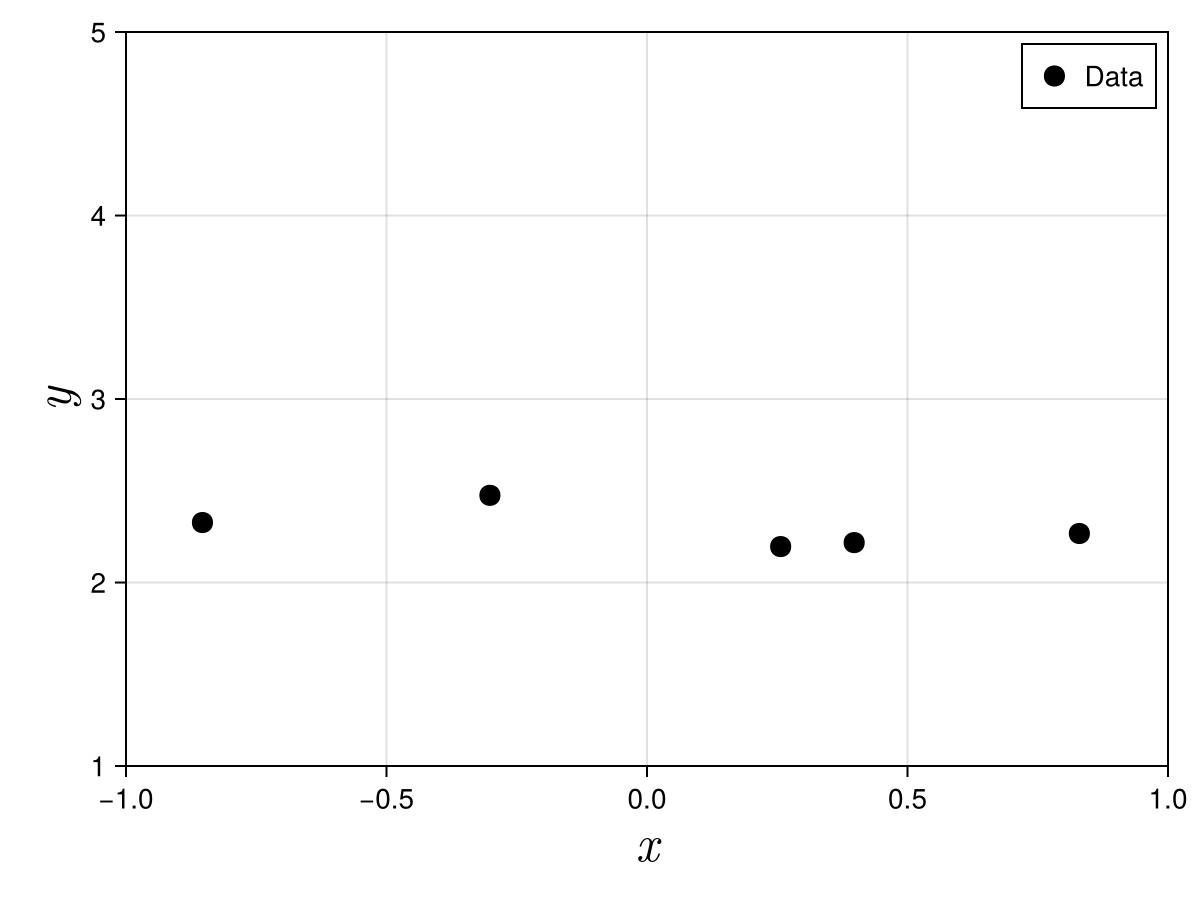

CairoMakie.Screen{IMAGE}


In [2]:
N_SAMPLES=5
rng=Xoshiro(1) #my random number generator

xi=rand(rng,Uniform(-1,1),N_SAMPLES) #generate random values of x between -1 and 1
yi=rand(rng,Normal(2.3,0.1),N_SAMPLES)

fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"y",
    xlabelsize=25,
    ylabelsize=25,
    limits=(-1,1,1,5),
    backgroundcolor = :transparent)
scatter!(ax,xi,yi;label="Data",color=:black,markersize=15)
axislegend(ax;position = :rt)
save("../figures/03p01LinearLeastSquaresGradientDescent01.png", fig)
display(fig)


The fictitious data that I generated above looks like $y_i$ is almost a constant. It does not look like it is changing with $x$. I am going to model this data with a model

$f_{model}(a_0,x)=a_0$

This model is a constant because my data looks like is it almost constant.  So we need to find $a_0$ such that $f_{model}(a,x)$ is as close to our data is possible.  To do this, we need to define a "mean" error

$
  S=\frac{1}{2}\sum\limits_{i=1}^{5} e_i^2
$

where $e_i=y_i-a_0$

In [3]:
f_model(a0,xi)=a0
S(a0)=(1/2)*sum((yi.-f_model.(a0,xi)).^2)

S (generic function with 1 method)

If we plot $S$ for different values of $a\in [0,5]$, we will see that we have a value of $a$ where $S$ is minimum.  We would like to find this value of $a$. 

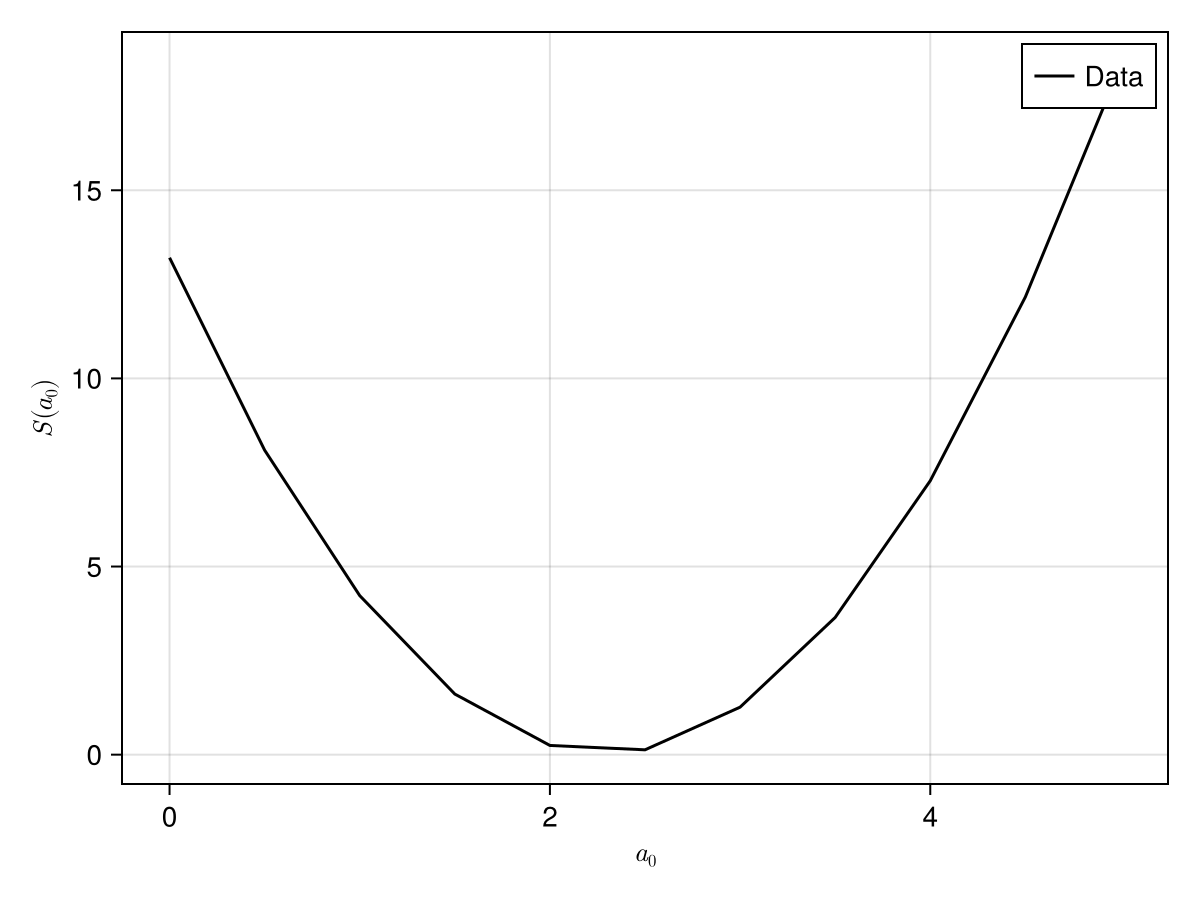

In [4]:
avec=0:0.5:5
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"a_0", ylabel = L"S(a_0)")
lines!(ax,avec,S.(avec);label="Data",color=:black)
axislegend(ax;position = :rt)
fig


Formula for the derivative

$
\frac{\partial S}{\partial a_0}  =-\sum\limits_{i=1}^{N} (y_i-a_0)
$

In [5]:
dSda(a0)=-sum(yi.-f_model.(a0,xi))


dSda (generic function with 1 method)

Using gradient descent to find most optimum value of $a_0$

In [6]:
a0=3.0
α=0.001

for i=1:1000
    a0-=α*dSda(a0)
end

If our machine learning has been conducted properly, the value of $a_0 \approx 2.3$ (since the data is generated from a constant value of 2.3 + a small amount of noise)

In [10]:
a0

2.3010736078239535

Now let's plot our model with our original data

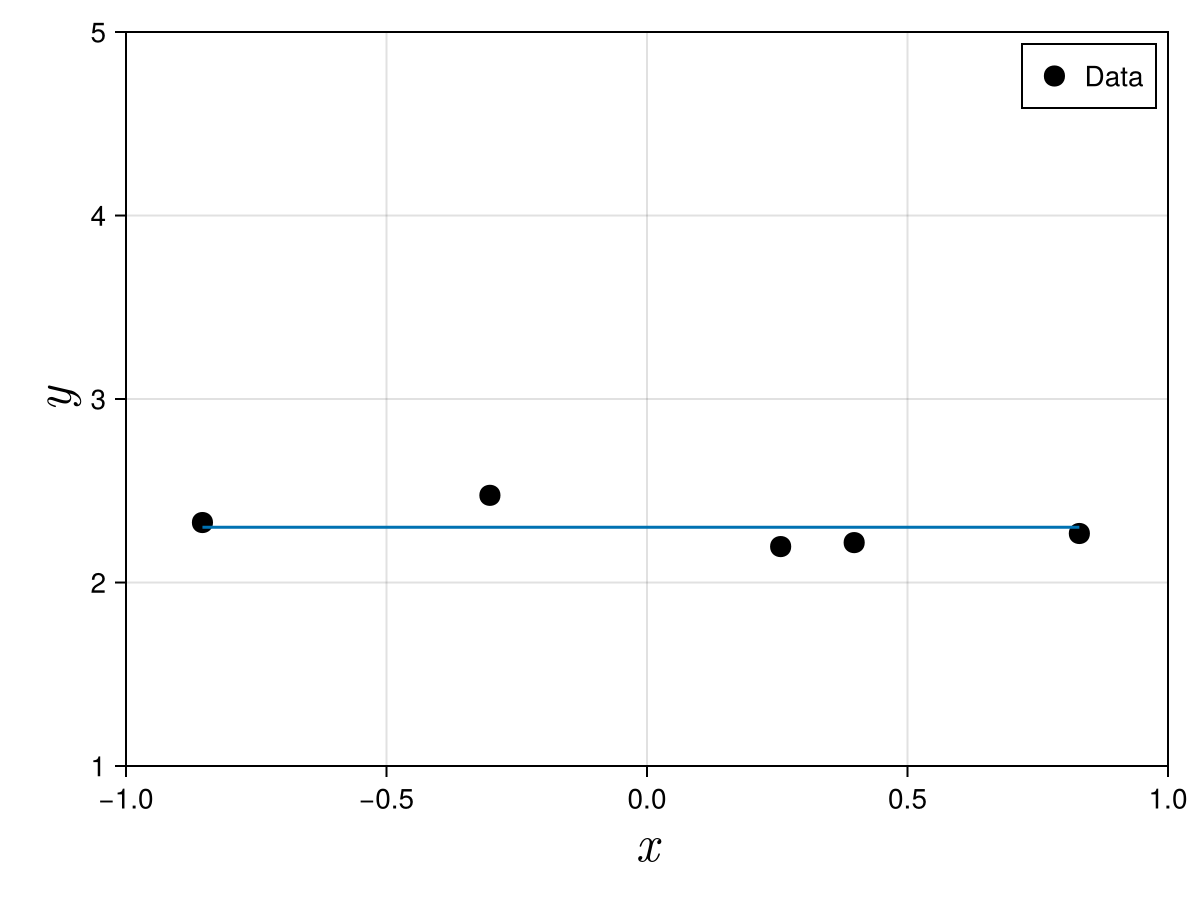

CairoMakie.Screen{IMAGE}


In [11]:
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"y",
    xlabelsize=25,
    ylabelsize=25,
    limits=(-1,1,1,5),
    backgroundcolor = :transparent)
scatter!(ax,xi,yi;label="Data",color=:black,markersize=15)
lines!(ax,xi,f_model.(a0,xi))
axislegend(ax;position = :rt)
display(fig)

As can be seen above, the model fits the data pretty well!

---

In this next example, we will try to find a model that fits the fictitious data from the function 

$
y=2x + 3 +\epsilon
$

where $x \in [-1,1]$.  $\epsilon$ is some small amount of noise.  

* For most problems, you do not know how the function looks like.  
* But here, I am going to generate data from a known function  and then I will find a model that fits the data. 
* The advantage of having data from a known function is that I can tell if my model is correct  and check if my process is right.
* For real problems, your data would come from your experiments, simulations and be stored in a spreadsheet.

Generating the fictious data

In [12]:
N_SAMPLES=50 #50 data points
rng=Xoshiro(1) #my random number generator

x_samples=rand(rng,Uniform(-1,1),N_SAMPLES) #generate random values of x between -1 and 1
y_noise=rand(rng,Normal(0.0,0.1),N_SAMPLES) #generate some noise, normal distribution with standard deviation of 0.1
y_samples=2.0.*(x_samples).+3.0.+y_noise; #y=2x+3+epsilon

Let's plot the data and see how it looks like

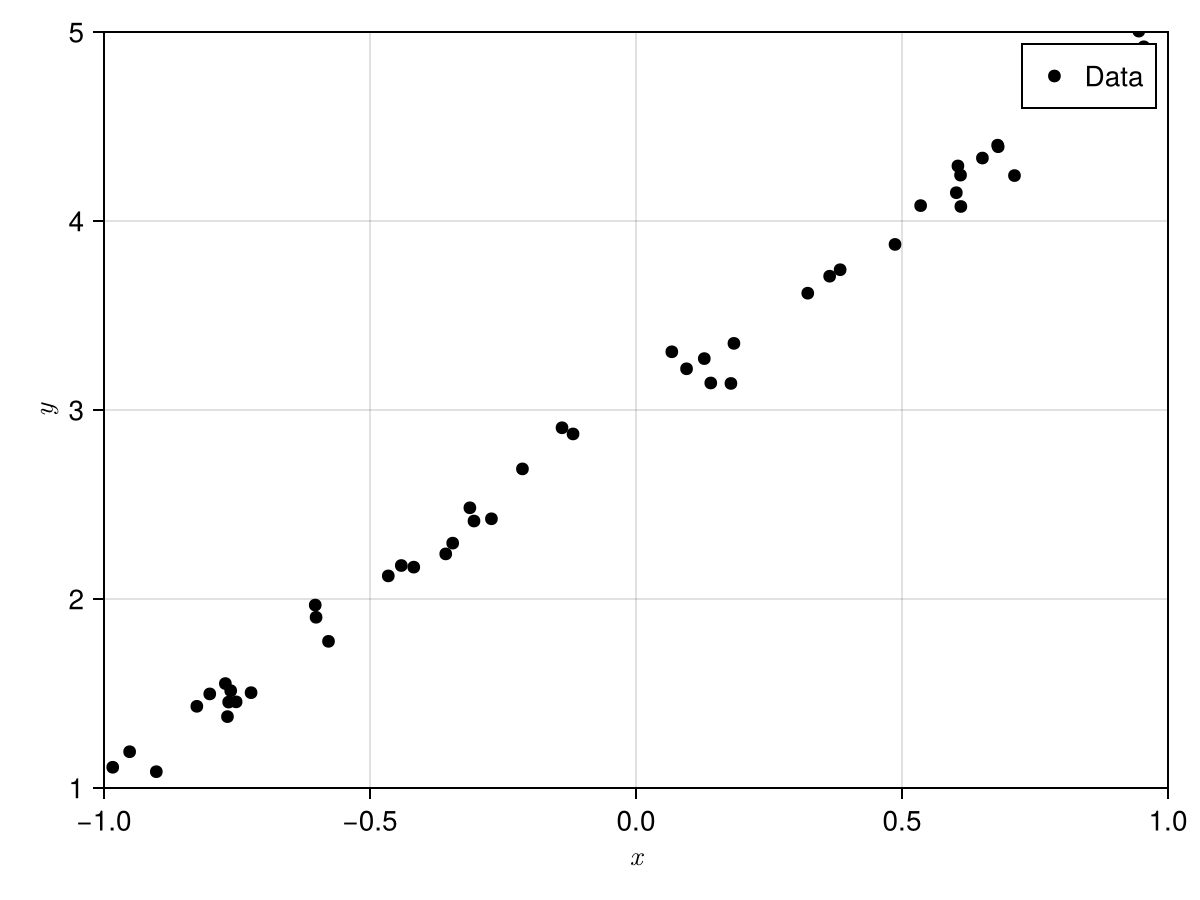

In [13]:
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"y",limits=(-1,1,1,5))
scatter!(ax,x_samples,y_samples;label="Data",color=:black)
axislegend(ax;position = :rt)
fig

We will define a model of the same form as the data.

$f_{model}(x)=a_0+a_1 x$

Hence, our task now is to find $a_0$ and $a_1$ such that $f_{model}(x)$ closely approximates $(x_i,y_i)$.  Remember that $a_0 \rightarrow $ a[1], $a_1 \rightarrow $ a[2].....since the indices in Julia starts with 1.

Since our model is exactly the same form as our data, if our program is right, we should get $a_0=3$ and $a_1=2$. 

In [14]:
fmodel(a,x)=a[1]*x.^0+a[2].*x;

* Since we fictitiously genenerate the data, we know that $f_{model}$ should fit the data best if $a_0=3$ and $a_1=2$.  
* Note that in real world example, we usually do not know $a_0$ and $a_1$.

We will now pretend we do not know the value of $a_0$ and $a_1$ and assume that they are both $1.0$. Let's plot $f_{model}(x)$ and see how it looks like if we assume that $a_0=a_1=1.0$. 

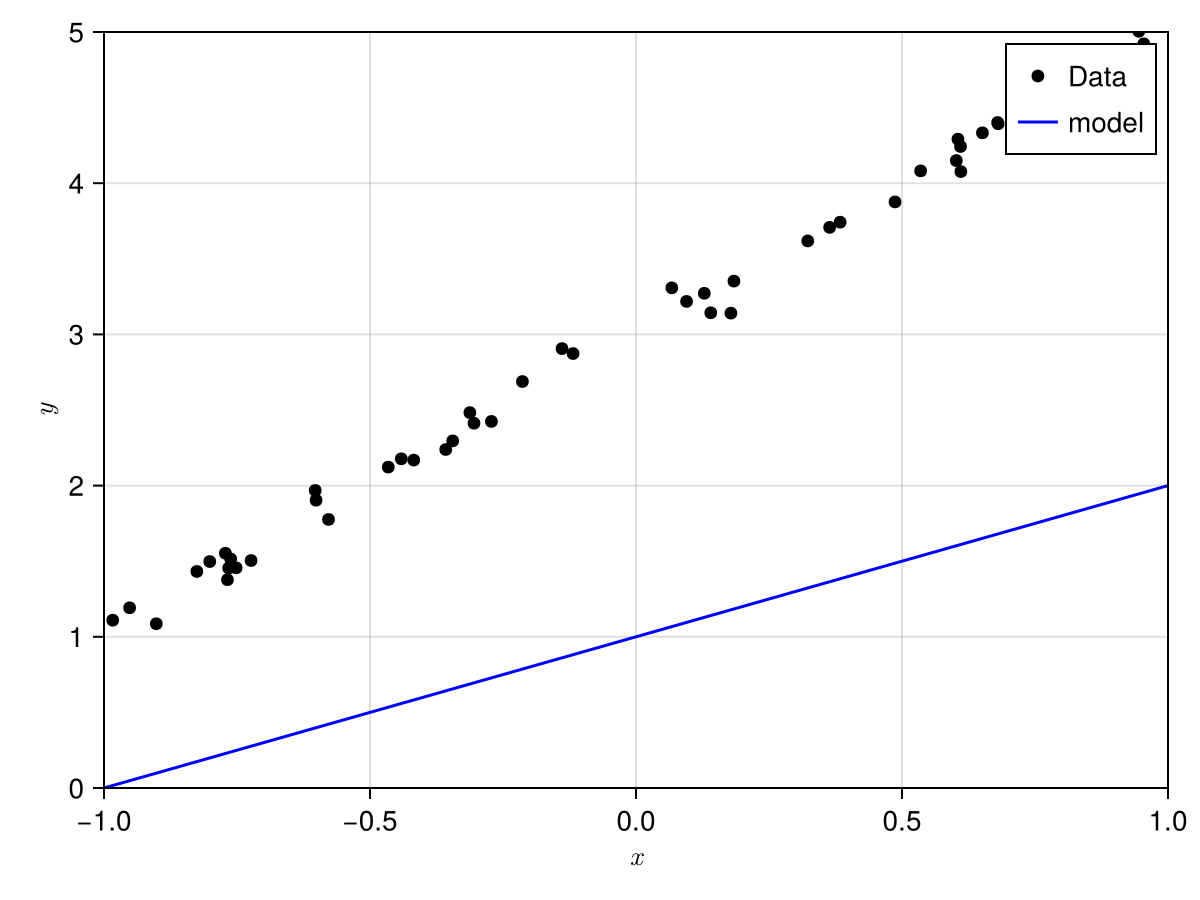

In [15]:
a=[1.0,1.0] #initial assumptions of the values of  a0, a1 
xplot=Array(-1:0.001:1)


fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"y",limits=(-1,1,0,5))
scatter!(ax,x_samples,y_samples;label="Data",color=:black)
lines!(ax,xplot,fmodel(a,xplot);label="model",color=:blue)
axislegend(ax;position = :rt)
fig

As can be seen from the graph above, $f_{model}$ is not a good match to the dataset.  We can quantify the error by defining a `custom loss` `S()` function

 As per the example above `S()` is defined as $S(\vec{a})=\frac{1}{2}\sum\limits_{i=1}^{N}(y_i-f_{model}(x_i))^2$. Remember that $\vec{a}$ in this example is a vector consisting of 2 scalar values, i.e. 

$\vec{a}=\begin{Bmatrix}a_0\\
a_1\end{Bmatrix}$.

 For $f_{model}(x) $ to best approximate the true function $y(x)$, we need to choose $a_0$ and $a_1$ such that $S(\vec{a})$ is as small as possible.

In [17]:
function S(parameters,x_samples)
           ŷ = fmodel(parameters, x_samples)
           sum(0.5*(y_samples .- ŷ).^2)
end

S (generic function with 2 methods)

Let's compute my `custom_loss()` for my current model with $a_0=a_1=1$.

In [18]:
S(a,x_samples)

110.40397528089665

The number above says that our current error between data and model is quite large $\approx 110.4...$


For this simple example, we can plot the `S()` function for different values of $a_0$ and $a_1$ and explore how this `S()` values changes for different values of $a_0$ and $a_1$.

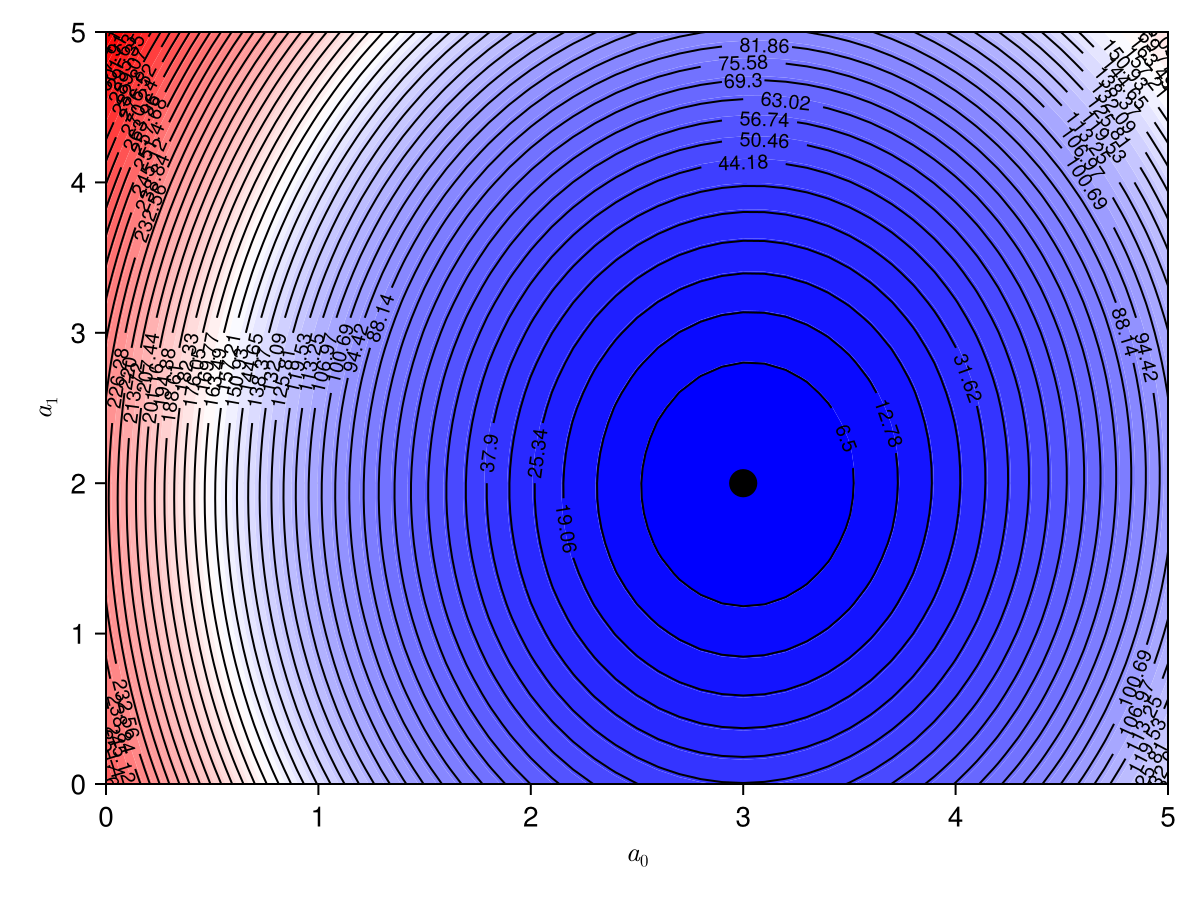

In [20]:
a0range=0:0.1:5
a1range=0:0.1:5
loss_values=[S([a0,a1],x_samples) for a0 in a0range, a1 in a1range]

fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"a_0", ylabel = L"a_1",limits=(0,5.0,0.0,5.0))
contourf!(ax,a0range,a1range,loss_values; levels=50, colormap=:bwr)
contour!(ax,a0range,a1range,loss_values; levels=50,labels=true, color=:black)
scatter!(ax,[3],[2];markersize=20,color=:black)
fig

As you can see, the `S()` function has a minimum at $(a_0,a_1)=(3,2)$, which is what we expect since we know for this simple example that the form of $f_{model}(x)$ is the same as my $y(x)$.  For real world data, that would not be the case. 

In the first example, we wrote our own gradient descent code to find the optimum value of $a_0$.  Here we will just use the optimization functions in Julia to find the values of $a_0$ and $a_1$ that  minimizes the `S()` function. 

In [24]:
a0=[1.0;1.0] #initial guess  of the values of  a0, a1.
optf = OptimizationFunction(S, ADTypes.AutoZygote())
prob = OptimizationProblem(optf,a0,x_samples) #first argument is the optimization function, second is the guess value and third is the parameter for optf()
sol= solve(prob,Optimisers.Descent(0.01),maxiters=50_000)

retcode: Default
u: 2-element Vector{Float64}:
 3.0202076492752683
 1.992093391991264

As expected, Julia finds the values of $a_0=3.0$ and $a_1=2.0$ which minimizes the `S()` function.  Let's now plot $f_{model}(x)$ with the new values of $a_0$ and $a_1$.

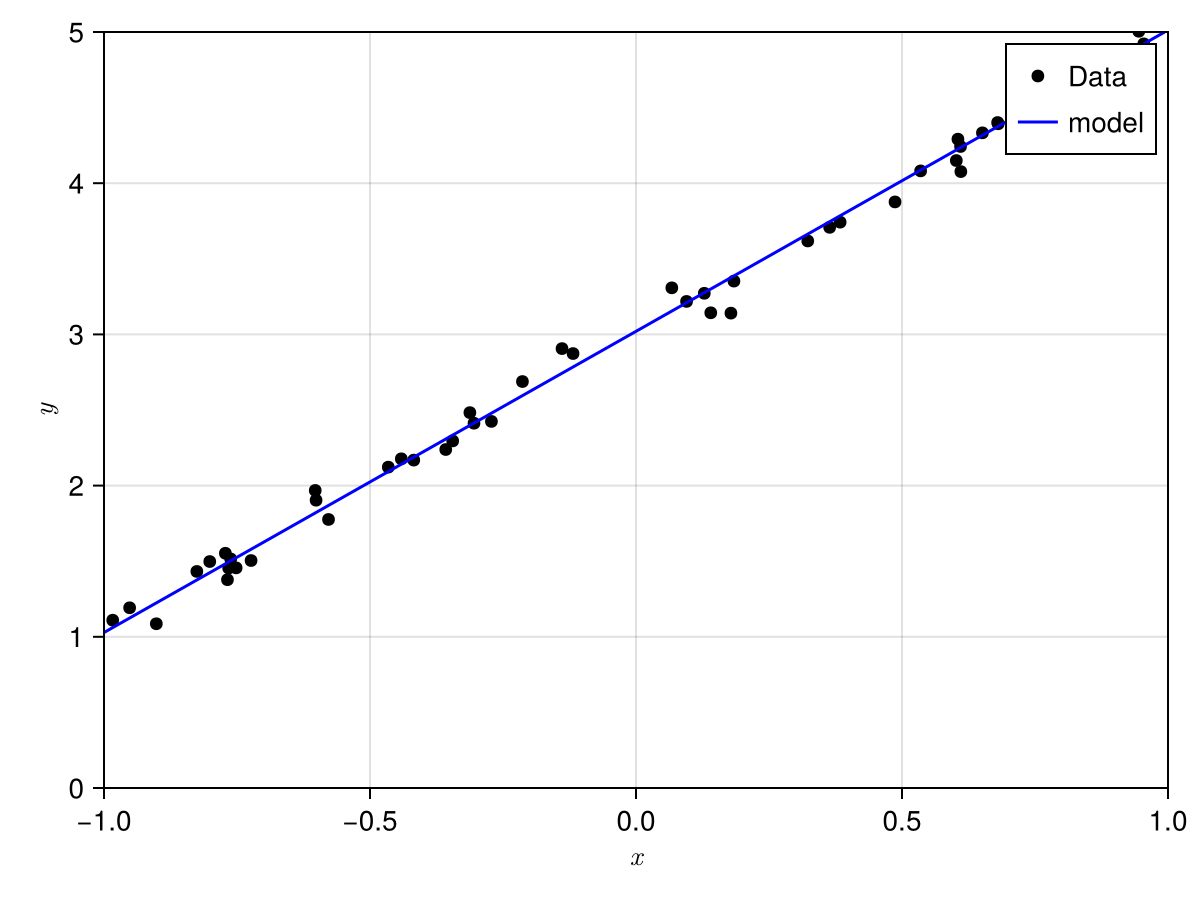

In [25]:
a=[sol.u[1],sol.u[2]] #initial assumptions of the values of  a0, a1 
xplot=Array(-1:0.001:1)


fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"y",limits=(-1,1,0,5))
scatter!(ax,x_samples,y_samples;label="Data",color=:black)
lines!(ax,xplot,fmodel(a,xplot);label="model",color=:blue)
axislegend(ax;position = :rt)
fig

Now $f_{model}(x)$ fits the data very well!

---
**Class Demo 01:** Generate a fictitious data set from the function

$
y=2x^2-10x+3+\epsilon
$

and use 

$f_{model}(x)=a_0+a_1 x+a_2 x^2$

$\epsilon$ is a small amount of random noise. Can you find a set of $a_0$, $a_1$ and $a_2$  that make $f_{model}(x)$ looks like $y_i$?  Use the domain $x\in[0,2\pi]$.  Here we will write our own Gradient Descent code to solve this problem.

---

Prepared by Andrew Ooi 8th July 2026